In [2]:
!wsl curl -o dataset/produccion-agricola.json "https://www.datos.gov.co/resource/t2ca-uae5.json?\$limit=50000"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0Warning: Failed to open the file dataset/produccion-agricola.json: No such 

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
curl: (23) client returned ERROR on write of 15464 bytes


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
#from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score,  precision_score, recall_score, f1_score
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, MinMaxScaler, FunctionTransformer, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from category_encoders.binary import BinaryEncoder
import phik
from phik import resources
from phik.binning import bin_data
from phik.decorators import *
from phik.report import  plot_correlation_matrix
import networkx as nx

In [ ]:
#Modelo semántico



In [115]:
df.sample(10).to_csv('data/sample.csv', index=False)

In [95]:
df = pd.read_json('data/produccion-agricola.json')
df.head()

,tipo,rubro,subregion,anio,municipio,area_total,area_produccion,volumen_produccion
0,Permanentes,Aguacate,Oriente,1990,Abejorral,45.0,23.0,138.0
1,Permanentes,Aguacate,Urabá,1990,Apartadó,29.0,27.0,405.0
2,Permanentes,Aguacate,Suroeste,1990,Montebello,17.0,12.0,78.0
3,Permanentes,Aguacate,Suroeste,1990,Santa Bárbara,150.0,140.0,980.0
4,Permanentes,Aguacate,Urabá,1990,Turbo,75.0,55.0,825.0


In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32721 entries, 0 to 32720
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   tipo                32721 non-null  object 
 1   rubro               32721 non-null  object 
 2   subregion           32721 non-null  object 
 3   anio                32721 non-null  int64  
 4   municipio           32721 non-null  object 
 5   area_total          32680 non-null  float64
 6   area_produccion     32287 non-null  float64
 7   volumen_produccion  32535 non-null  float64
dtypes: float64(3), int64(1), object(4)
memory usage: 2.0+ MB


In [97]:
df.describe()

,anio,area_total,area_produccion,volumen_produccion
count,32721.000000,32680.000000,32287.000000,3.253500e+04
mean,2009.716787,435.615817,399.454878,3.145023e+03
std,8.894551,1223.919511,1145.616547,2.322381e+04
min,1990.000000,0.000000,-1.000000,-1.065810e-14
25%,2003.000000,19.700000,15.000000,5.580000e+01
50%,2011.000000,76.000000,65.000000,2.880000e+02
75%,2017.000000,315.000000,285.000000,1.276000e+03
max,2022.000000,36000.000000,36000.000000,1.039280e+06


In [98]:
df.describe(include='O')

,tipo,rubro,subregion,municipio
count,32721,32721,32721,32721
unique,3,155,9,140
top,Permanentes,Café,Oriente,Medellín
freq,19753,2799,6802,732


c:\Users\USUARIO\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0, 0.5, 'Frecuencia')

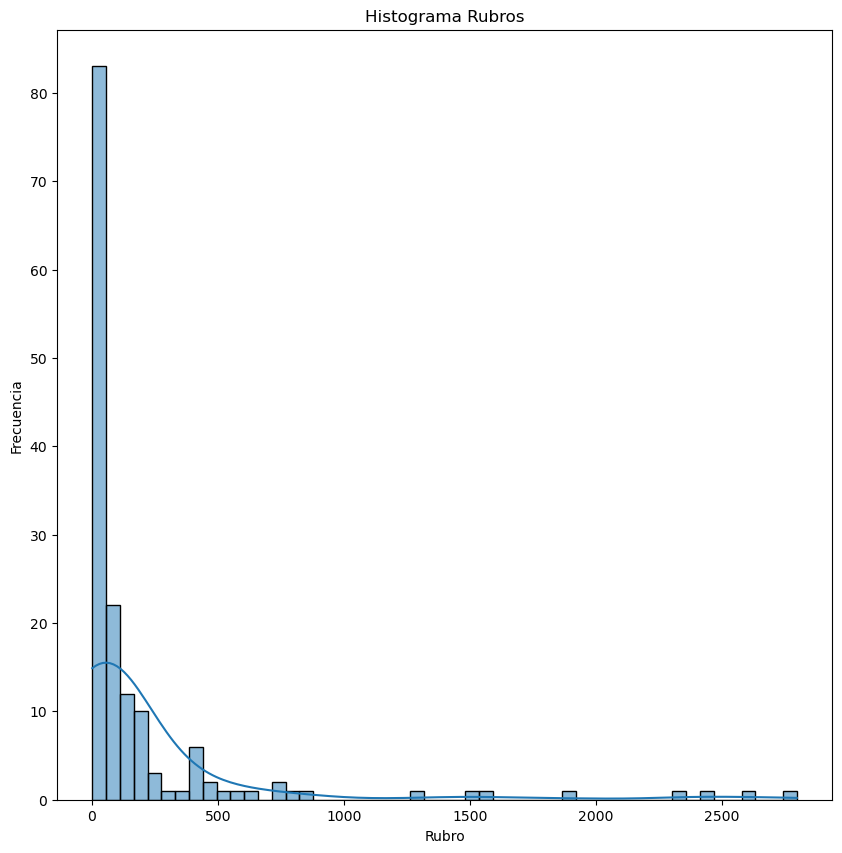

In [99]:
plt.figure(figsize=(10, 10))
sns.histplot(df['rubro'].value_counts(), kde=True)
plt.title('Histograma Rubros')
plt.xlabel('Rubro')
plt.ylabel('Frecuencia')

In [100]:
#media de valores por rubro
df['rubro'].value_counts().mean()

211.1032258064516

c:\Users\USUARIO\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0.5, 1.0, 'Municipios')

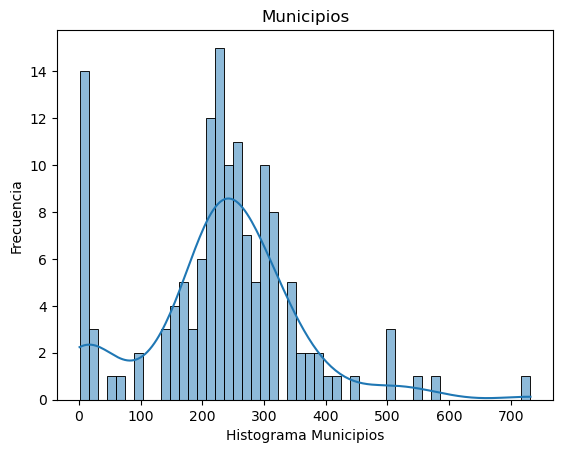

In [101]:
sns.histplot(df['municipio'].value_counts(), bins=50, kde=True)
plt.xlabel("Histograma Municipios")
plt.ylabel("Frecuencia")
plt.title("Municipios")

In [102]:
df.groupby(['tipo'])['volumen_produccion'].mean()

tipo
Anuales         2257.987454
Permanentes     3861.514644
Transitorios    2016.794965
Name: volumen_produccion, dtype: float64

Los términos "permanente", "transitorio" y "anual" se refieren a la duración del ciclo de vida de un cultivo y a la frecuencia con la que necesita ser sembrado.

Cultivo Permanente:
    Larga Duración: Su vida productiva es de varios años.
    Múltiples Cosechas: Se cosechan repetidamente a lo largo de su vida útil.
    No se Resiembra Anualmente: La planta no se destruye al cosechar y sigue produciendo en las siguientes temporadas.

Cultivo Transitorio (o de Ciclo Corto):
    Ciclo de Vida Corto: Generalmente menos de 12 meses, a veces tan solo de 3 a 6 meses.
    Una Sola Cosecha Principal por Siembra: Después de la cosecha, la planta muere o se retira.
    Requiere Resiembra: Es necesario volver a sembrar para cada nuevo ciclo de producción.

Cultivo Anual:
    Ciclo de Vida Anual: Completan su ciclo biológico en un año o menos.
    Siembra y Cosecha en el Mismo Año Agrícola: Se plantan y se cosechan dentro de un periodo de 12 meses.
    Necesidad de Resiembra: Al igual que los transitorios, deben ser replantados después de cada cosecha.

Text(0.5, 1.0, 'Tipos de cultivo')

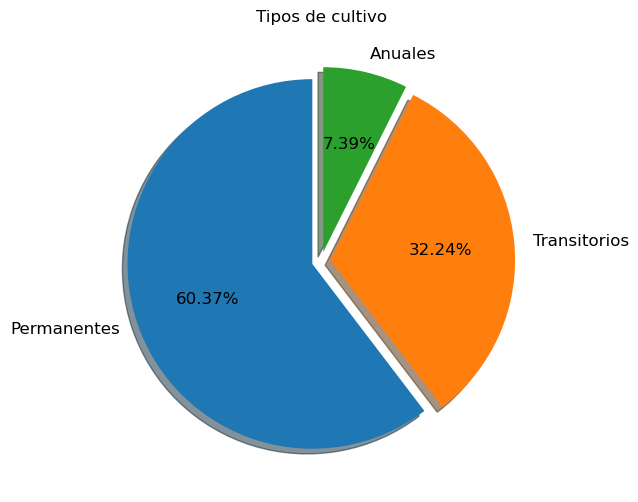

In [103]:
plt.figure(figsize=(10, 6))
plt.pie(df['tipo'].value_counts(), 
        labels=df['tipo'].unique(), 
        autopct='%0.2f%%', startangle=90, shadow=True, 
        explode=(0.05, 0.05, 0.05),      
        textprops={'fontsize': 12} )
plt.title('Tipos de cultivo')

Text(0.5, 1.0, 'Top 10 Rubros')

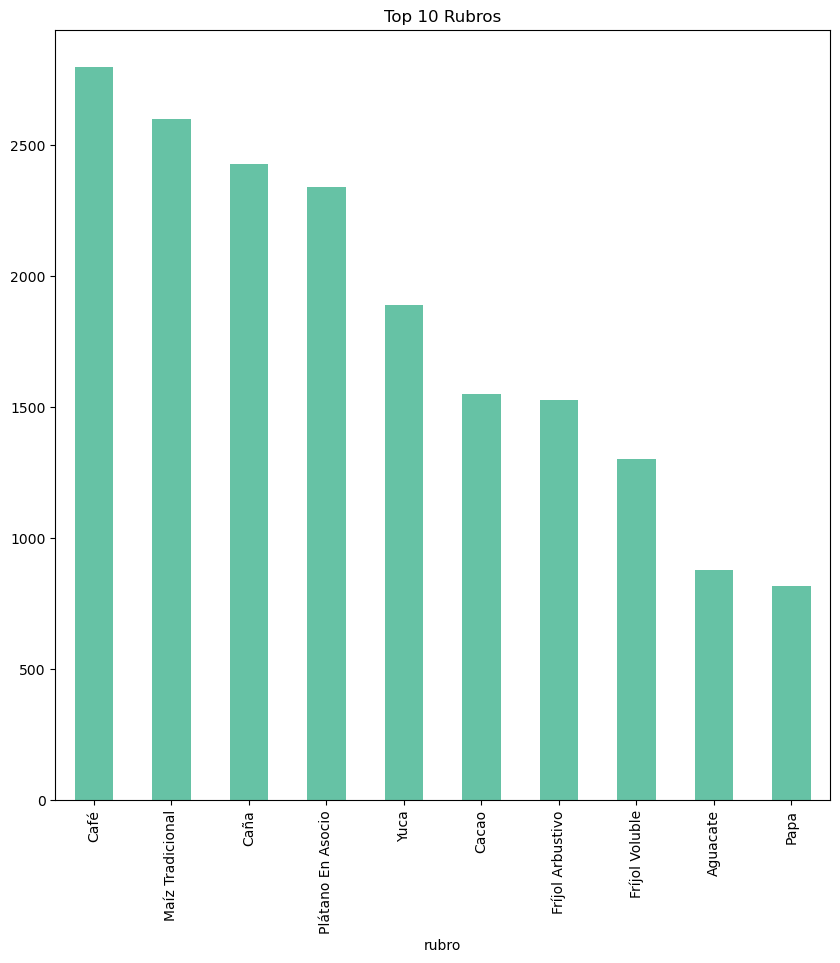

In [104]:
plt.figure(figsize=(10, 10))
df['rubro'].value_counts().head(10).plot(kind='bar', colormap='Set2')
plt.title('Top 10 Rubros')

c:\Users\USUARIO\anaconda3\Lib\site-packages\seaborn\axisgrid.py:848: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\USUARIO\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\USUARIO\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\USUARIO\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

Text(0.5, 1.0, 'Producción 1990-2022')

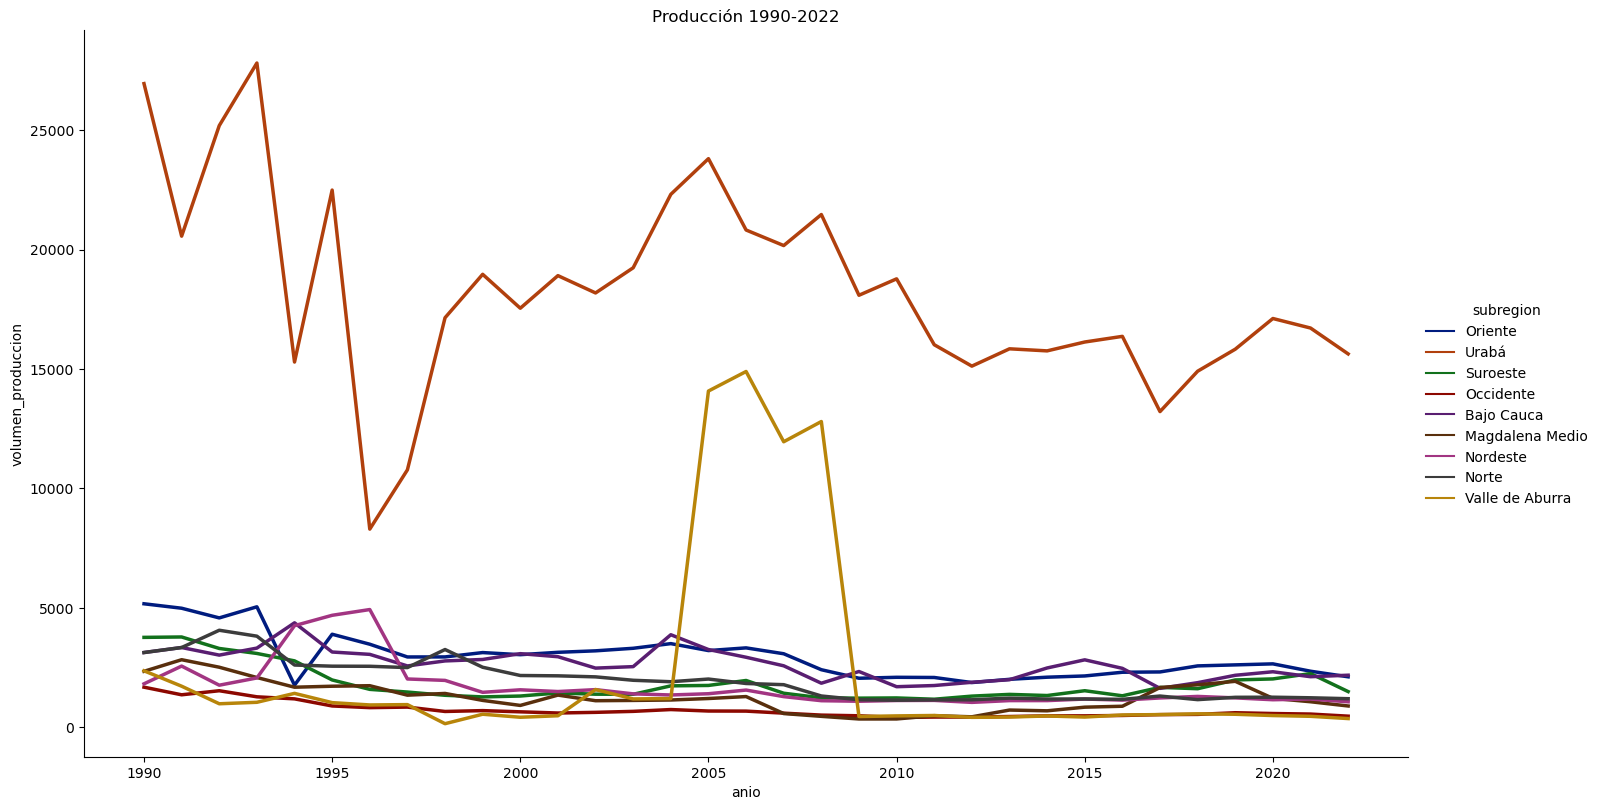

In [105]:
grafico = sns.relplot(
    x='anio',
    y='volumen_produccion',
    data=df,
    hue='subregion',
    kind='line',
    height=8,  # Altura en pulgadas
    aspect=1.8,  # Relación ancho/alto
    palette='dark',  # Mejor esquema de colores
    linewidth=2.5,
    ci=None,  # Elimina intervalo de confianza si no es necesario
    legend='full'
)

# Personalización avanzada
plt.title('Producción 1990-2022')

In [106]:
#calcular rendimiento por hectárea
df['volumen_produccion']/df['area_produccion']

0         6.0
1        15.0
2         6.5
3         7.0
4        15.0
         ... 
32716     5.0
32717     2.0
32718     5.0
32719    13.5
32720     6.0
Length: 32721, dtype: float64

In [107]:
#calcular calidad de la tierra por hectárea
df['area_produccion']/df['area_total']

0        0.511111
1        0.931034
2        0.705882
3        0.933333
4        0.733333
           ...   
32716    1.000000
32717    0.304348
32718    1.000000
32719    1.000000
32720    1.000000
Length: 32721, dtype: float64

<Axes: title={'center': 'Rubros por subregión'}, xlabel='subregion'>

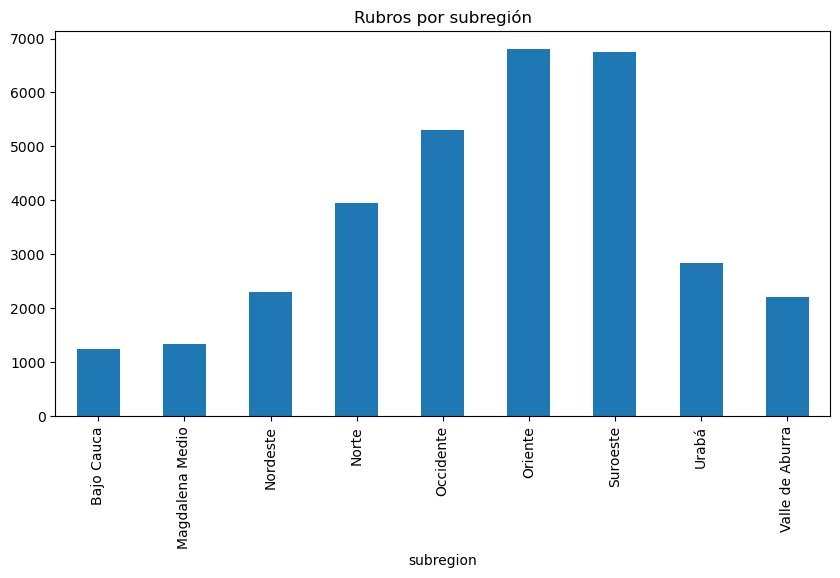

In [108]:
df.groupby('subregion')['rubro'].count().plot(kind='bar', title='Rubros por subregión', figsize=(10, 5))

<Axes: title={'center': 'Top 10 Rubros Urabá'}, xlabel='rubro'>

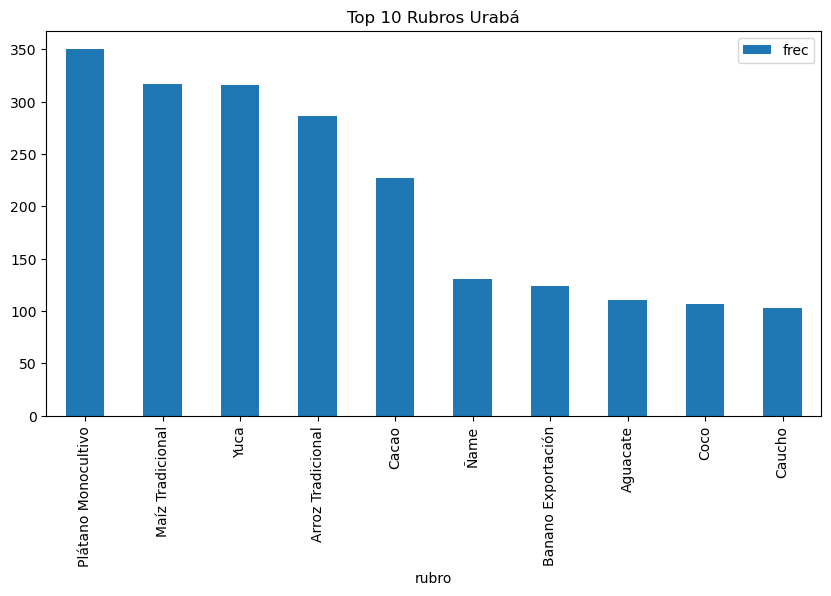

In [109]:
df[df['subregion']=='Urabá'].groupby(['subregion', 'rubro']).size().reset_index(name='frec').sort_values(by=['frec'], ascending=False).head(10).plot(kind='bar', x='rubro', y='frec', title='Top 10 Rubros Urabá', figsize=(10, 5))

<Axes: title={'center': 'Top 10 Rubros Oriente'}, xlabel='rubro'>

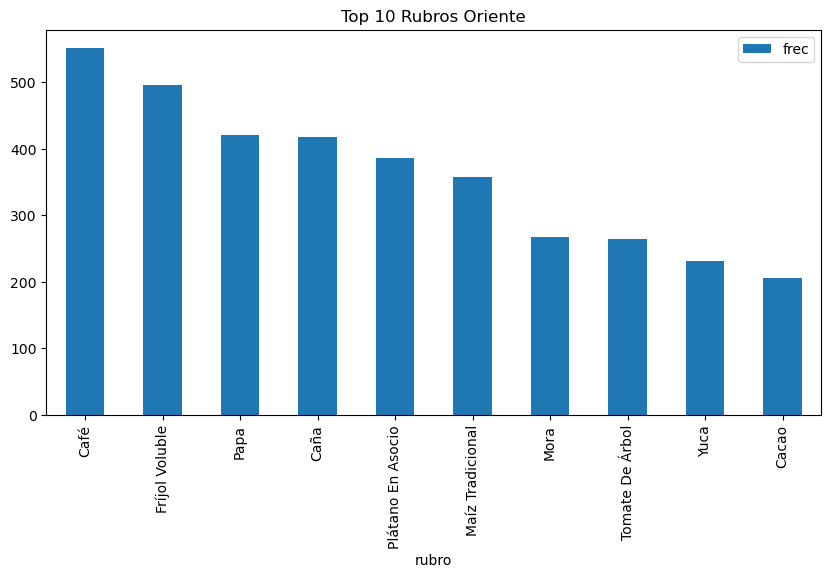

In [110]:
df[df['subregion']=='Oriente'].groupby(['subregion', 'rubro']).size().reset_index(name='frec').sort_values(by=['frec'], ascending=False).head(10).plot(kind='bar', x='rubro', y='frec', title='Top 10 Rubros Oriente', figsize=(10, 5))

In [111]:
#de que tipo son los rubros mas comunes
df.groupby(['tipo', 'rubro']).size().reset_index(name='frec').sort_values(by='frec', ascending=False).head(10)

,tipo,rubro,frec
29,Permanentes,Café,2799
145,Transitorios,Maíz Tradicional,2599
33,Permanentes,Caña,2429
101,Permanentes,Plátano En Asocio,2338
7,Anuales,Yuca,1889
28,Permanentes,Cacao,1550
137,Transitorios,Fríjol Arbustivo,1526
139,Transitorios,Fríjol Voluble,1302
14,Permanentes,Aguacate,876
146,Transitorios,Papa,816


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_15636\1488891701.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  barras = sns.barplot(data=df, y='volumen_produccion', x='subregion', hue='tipo', ci=None, palette='dark')


Text(0.5, 1.0, 'Producción por subregión y tipo')

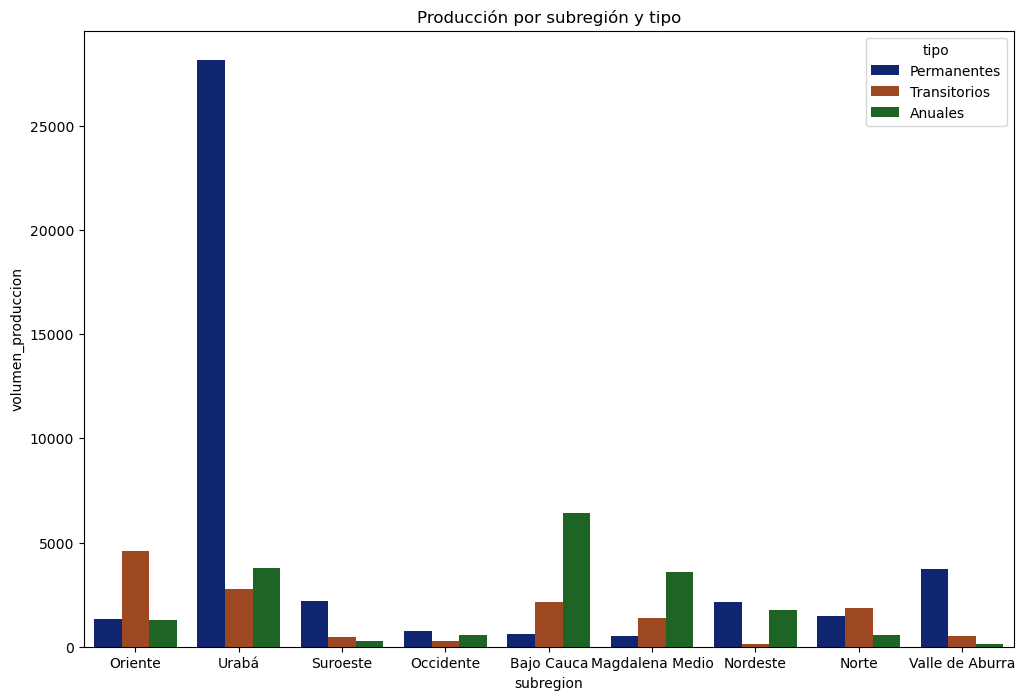

In [112]:
plt.figure(figsize=(12, 8)) 
barras = sns.barplot(data=df, y='volumen_produccion', x='subregion', hue='tipo', ci=None, palette='dark')
barras.set_title('Producción por subregión y tipo')

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_15636\2750761905.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  barras = sns.barplot(data=df, y='area_total', x='subregion', hue='tipo', ci=None, palette='dark')


Text(0.5, 1.0, 'Area sembrada por subregión y tipo')

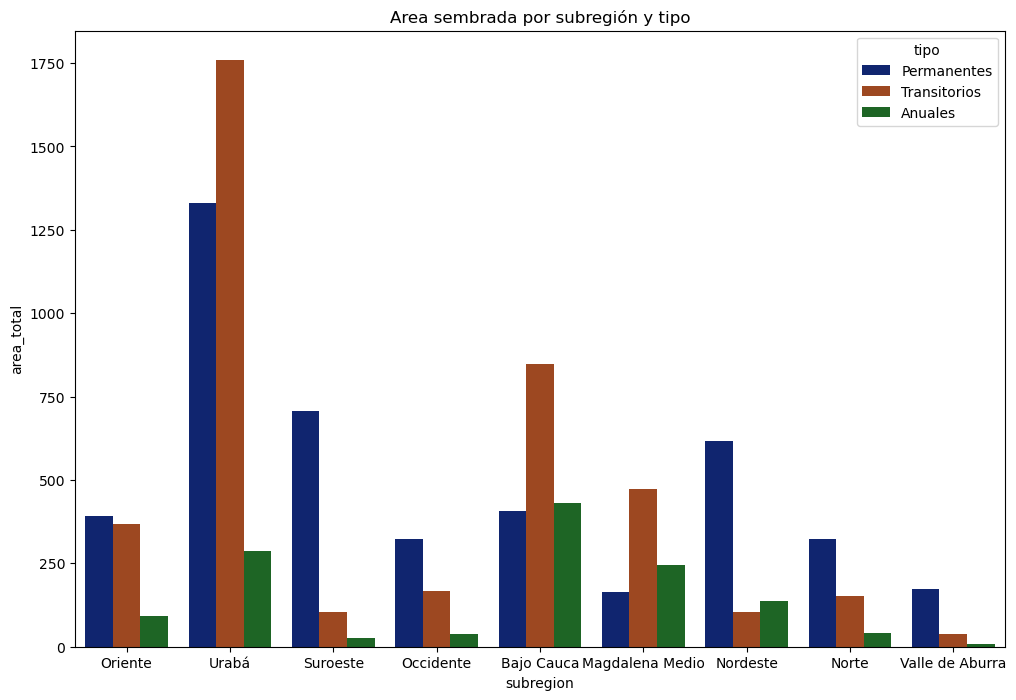

In [113]:
plt.figure(figsize=(12, 8)) 
barras = sns.barplot(data=df, y='area_total', x='subregion', hue='tipo', ci=None, palette='dark')
barras.set_title('Area sembrada por subregión y tipo')

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_15636\3064996911.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  barras = sns.barplot(data=df, y='area_produccion', x='subregion', hue='tipo', ci=None, palette='dark')


Text(0.5, 1.0, 'Area cosechada por subregión y tipo')

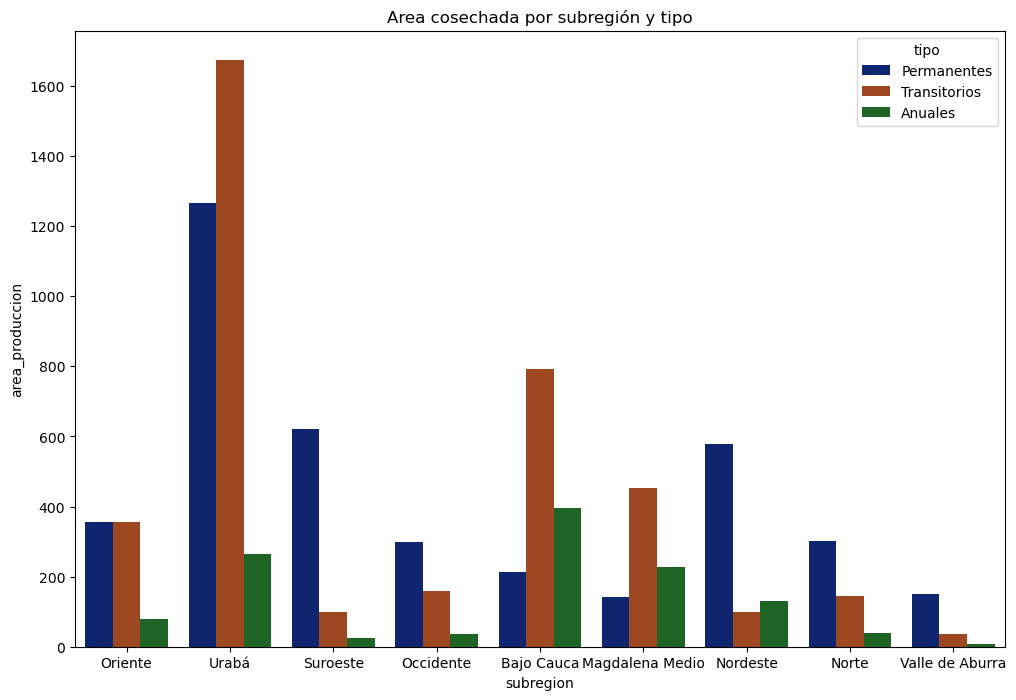

In [114]:
plt.figure(figsize=(12, 8)) 
barras = sns.barplot(data=df, y='area_produccion', x='subregion', hue='tipo', ci=None, palette='dark')
barras.set_title('Area cosechada por subregión y tipo')

Diagrama de cajas para visualizar valores atípicos

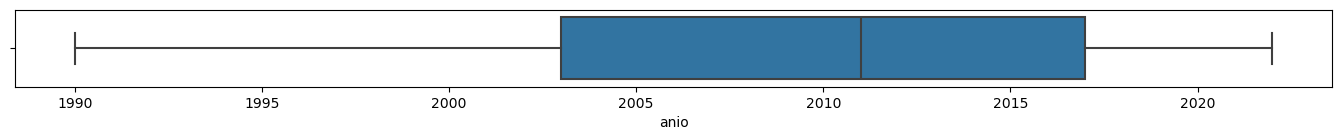

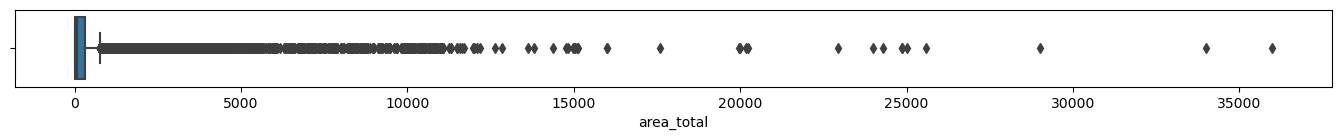

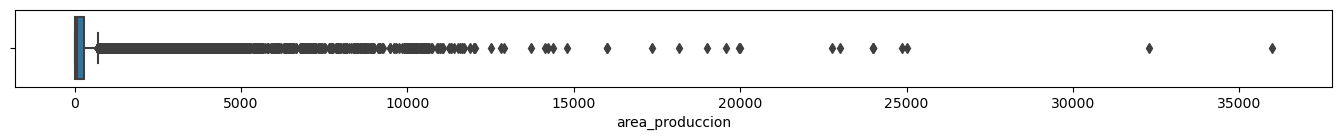

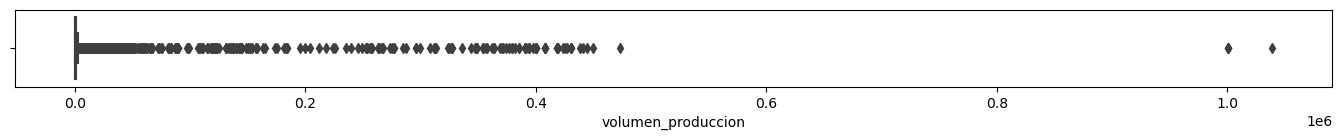

In [115]:
cols = df.select_dtypes(include='number').columns
for i in cols:
  plt.figure(figsize=(17,1))
  sns.boxplot(data=df[cols], x=i)

interval columns not set, guessing: ['anio', 'area_total', 'area_produccion', 'volumen_produccion']


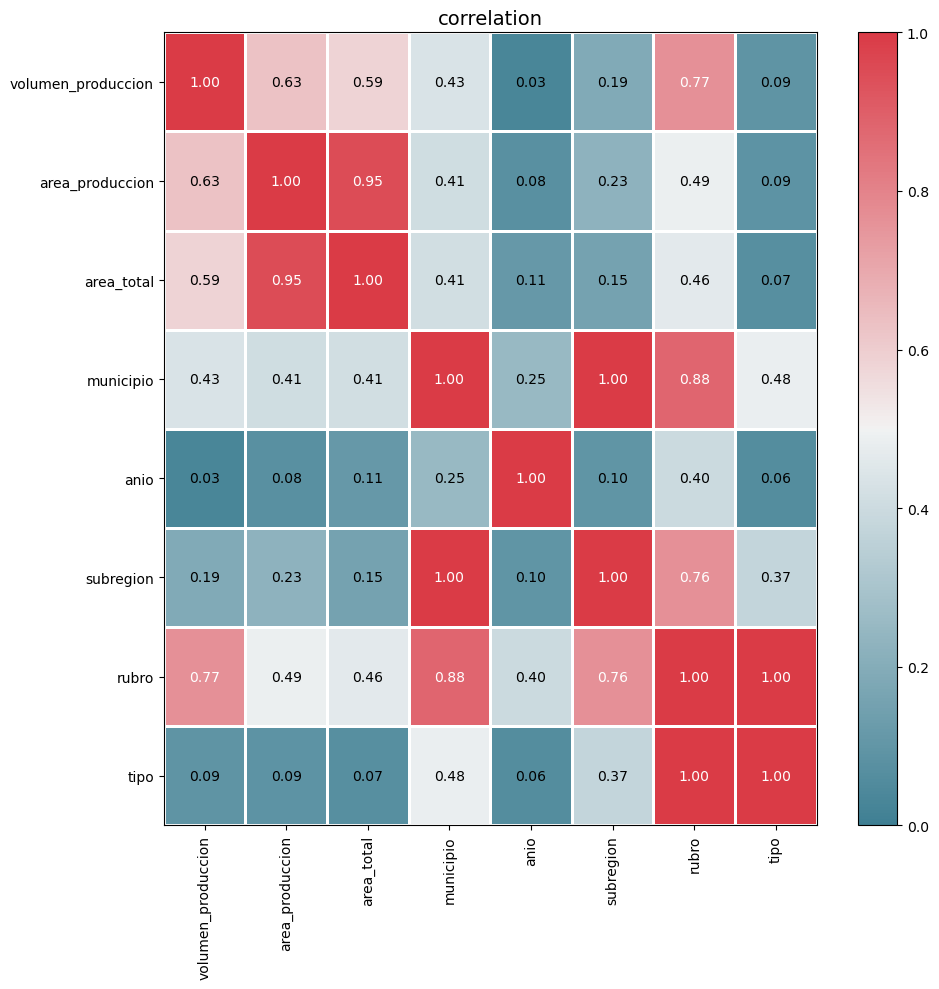

In [3]:
corre = df.phik_matrix()
cma = sns.diverging_palette(220, 10, as_cmap=True)

plot_correlation_matrix(corre.values, x_labels=corre.columns, y_labels=corre.index, vmin=0, vmax=1, color_map=cma, figsize=(10,10))

In [ ]:
#Agrupar en "Otros"
for i in df.select_dtypes(include='O').columns:
    counts = df[i].value_counts()
    to_group = counts[counts < 50].index
    df[i] = df[i].apply(lambda x: 'Otros' if x in to_group else x)

df[df['municipio'] == 'Otros']

,tipo,rubro,subregion,anio,municipio,area_total,area_produccion,volumen_produccion
2582,Transitorios,Papa,Norte,1995,Otros,10.0,10.0,280.0
3237,Transitorios,Papa,Norte,1996,Otros,11.0,11.0,310.0
3892,Transitorios,Papa,Norte,1997,Otros,12.0,12.0,204.0
4554,Permanentes,Naranja Valencia,Suroeste,1998,Otros,18.0,15.0,300.0
4579,Transitorios,Papa,Norte,1998,Otros,14.0,14.0,246.0
...,...,...,...,...,...,...,...,...
32391,Permanentes,Plátano En Asocio,Suroeste,2022,Otros,11.0,6.0,24.0
32517,Transitorios,Tomate Chonto,Valle de Aburra,2022,Otros,2.0,1.8,12.6
32592,Transitorios,Tomate Chonto Bajo Invernadero,Valle de Aburra,2022,Otros,2.0,2.0,120.0
32664,Anuales,Yuca,Suroeste,2022,Otros,2.5,1.5,12.0


Text(0.5, 1.0, 'Rubros después de agrupar')

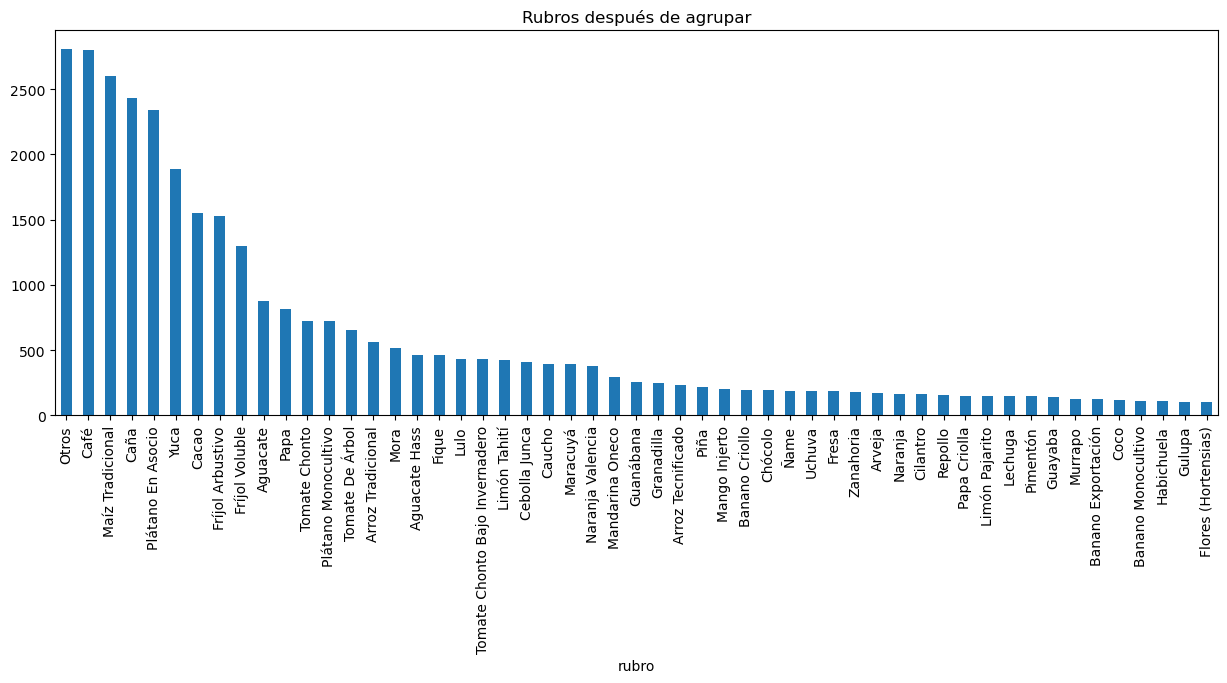

In [66]:
df['rubro'].value_counts().plot(kind='bar', figsize=(15,5))
plt.title("Rubros después de agrupar")


In [ ]:
print(f"Total duplicados: {df.duplicated().sum()}")
print(f"Visualizar duplicados:\n{df[df.duplicated()]}")
df.drop_duplicates(inplace=True)
print(f"Eliminar duplicados... Total duplicados: {df.duplicated().sum()}")

Total duplicados: 16
Visualizar duplicados:
               tipo                rubro        subregion  anio  \
2268    Permanentes                 Caña            Norte  1995   
2554    Permanentes              Naranja        Occidente  1995   
2630    Permanentes    Plátano En Asocio            Norte  1995   
5292    Permanentes                 Mora            Norte  1999   
5432    Permanentes    Plátano En Asocio         Nordeste  1999   
5435    Permanentes    Plátano En Asocio         Nordeste  1999   
13067   Permanentes  Plátano Monocultivo       Bajo Cauca  2008   
13078   Permanentes                Otros            Urabá  2008   
13637  Transitorios                Otros            Norte  2009   
18909   Permanentes                Otros            Urabá  2013   
19769  Transitorios                Otros            Norte  2014   
22441   Permanentes                Otros         Suroeste  2016   
26056  Transitorios                Otros  Valle de Aburra  2018   
27254   Permanente

In [ ]:
#Separar variable dependiente e independiente
X=df.drop('rubro', axis=1)
y=df['rubro']
X.shape, y.shape

((32705, 7), (32705,))

In [ ]:
#codificar variable dependiente
le = LabelEncoder()
le.fit(y)
Y_encoded = le.transform(y)
print(Y_encoded)

[ 0  0  0 ... 38 38 38]


In [ ]:
#separar datos en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, random_state=42) no es necesario porque en gridSearch se hace validacion cruzada
X_train.shape, X_test.shape

((26164, 7), (6541, 7))

In [ ]:
#para hacer FunctionTransformer nos basamos en
#https://www.youtube.com/watch?v=xIqX1dqcNbY

def imputer(df):
    df=df.copy()
    areas = df[['area_total', 'area_produccion', 'volumen_produccion']].columns
    for i in df['tipo'].unique():
        for j in areas:
            media = df[df['tipo'] == i][j].mean()
            df.loc[df['tipo'] == i, j] = df.loc[df['tipo'] == i, j].fillna(media)
    return df

preprocess_imputer = FunctionTransformer(imputer)

In [ ]:
#para hacer ColumnTransformer nos basamos en
#https://www.youtube.com/watch?v=irHhDMbw3xo

column_trans = ColumnTransformer(
    transformers=[
        ('cat_nominal', OneHotEncoder(), ['subregion']),
        ('cat_ordinal', OrdinalEncoder(), ['tipo']),
        ('cat_binary', BinaryEncoder(), ['municipio']),  #para hacer binary encoder nos basamos en https://www.youtube.com/watch?v=NuZuJL6TqI0
        ('num', MinMaxScaler(), ['area_total', 'area_produccion', 'volumen_produccion', 'anio'])
    ],
    remainder='passthrough'  # Mantener las columnas no transformadas
)

In [ ]:
#funcion para crear el pipeline
def create_pipeline(model):
    pipeline = Pipeline([
        #('duplicates', preprocess_duplicates),
        ('impute_nulls', preprocess_imputer),
        ('Encoders', column_trans),
        ('model', model)
    ])
    return pipeline

In [ ]:
#diccionario con los modelos y sus hiperparámetros
models = {
    'Logistic Regression': {
        'model': LogisticRegression(), 
        'hyperparameters' : {
            'model__C': [0.1, 1, 10],
            'model__penalty': ['l2'],
            'model__solver': ['lbfgs'],
            'model__max_iter': [100, 200, 500],
            'model__multi_class': ['multinomial', 'ovr']
        }
    },
    'SVM': {
        'model': SVC(), 
        'hyperparameters' : {
            'model__C': [0.1, 1, 10],
            'model__kernel': ['linear', 'rbf'],
            'model__gamma': ['scale', 'auto']
        }
    },
    'KNN': {
        'model': KNeighborsClassifier(), 
        'hyperparameters' : {
            'model__n_neighbors': [3, 5, 7],
            'model__weights': ['uniform', 'distance'],
            'model__algorithm': ['auto'],
            'model__metric': ['minkowski']
        }
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(), 
        'hyperparameters' : {
            'model__criterion': ['gini', 'entropy'],
            'model__splitter': ['best'],
            'model__max_depth': [None, 10, 20],
            'model__max_features': ['sqrt', 'log2', None]
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(), 
        'hyperparameters' : {
            'model__n_estimators': [50, 100],
            'model__criterion': ['gini', 'entropy'],
            'model__max_depth': [None, 10, 20],
            'model__max_features': ['sqrt', 'log2']
        }
    },
    'GaussianNB': {
        'model': GaussianNB(), 
        'hyperparameters' : {
            'model__var_smoothing': [1e-9, 1e-8]
        }
    }
}

In [ ]:
#Recorremos el diccionario models que contiene el modelo y los distintos hiperparámetros
#gridSearchCV escoge los mejores hiperparámetros
#en una lista guardamos los mejores modelos

lista_pipelines = []
for i, j in models.items():
    try:
        print(f"\nEntrenando modelo: {j['model']}")
        k = create_pipeline(j['model'])
        print(f"Hiperparámetros: {j['hyperparameters']}")

        grid_s = GridSearchCV(estimator=k, param_grid=j['hyperparameters'], verbose=1, cv=3)
        print("GridSearchCV...")
        grid_s.fit(X_train, y_train)
        print(f'{i} mejores parámetros: {grid_s.best_params_}\n')

        lista_pipelines.append(grid_s.best_estimator_)
    except Exception as e:
        print(f'Error en modelo {i}: {e}\n')


Entrenando modelo: LogisticRegression()
Hiperparámetros: {'model__C': [0.1, 1, 10], 'model__penalty': ['l2'], 'model__solver': ['lbfgs'], 'model__max_iter': [100, 200, 500], 'model__multi_class': ['multinomial', 'ovr']}
GridSearchCV...
Fitting 3 folds for each of 18 candidates, totalling 54 fits


c:\Users\USUARIO\anaconda3\Lib\site-packages\category_encoders\ordinal.py:210: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[column].fillna(-1, inplace=True)
c:\Users\USUARIO\anaconda3\Lib\site-packages\category_encoders\ordinal.py:210: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy

Logistic Regression mejores parámetros: {'model__C': 10, 'model__max_iter': 500, 'model__multi_class': 'multinomial', 'model__penalty': 'l2', 'model__solver': 'lbfgs'}


Entrenando modelo: SVC()
Hiperparámetros: {'model__C': [0.1, 1, 10], 'model__kernel': ['linear', 'rbf'], 'model__gamma': ['scale', 'auto']}
GridSearchCV...
Fitting 3 folds for each of 12 candidates, totalling 36 fits


c:\Users\USUARIO\anaconda3\Lib\site-packages\category_encoders\ordinal.py:210: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[column].fillna(-1, inplace=True)
c:\Users\USUARIO\anaconda3\Lib\site-packages\category_encoders\ordinal.py:210: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy

SVM mejores parámetros: {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'rbf'}


Entrenando modelo: KNeighborsClassifier()
Hiperparámetros: {'model__n_neighbors': [3, 5, 7], 'model__weights': ['uniform', 'distance'], 'model__algorithm': ['auto'], 'model__metric': ['minkowski']}
GridSearchCV...
Fitting 3 folds for each of 6 candidates, totalling 18 fits


...

c:\Users\USUARIO\anaconda3\Lib\site-packages\category_encoders\ordinal.py:210: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[column].fillna(-1, inplace=True)
c:\Users\USUARIO\anaconda3\Lib\site-packages\category_encoders\ordinal.py:210: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy

Random Forest mejores parámetros: {'model__criterion': 'entropy', 'model__max_depth': None, 'model__max_features': 'sqrt', 'model__n_estimators': 100}


Entrenando modelo: GaussianNB()
Hiperparámetros: {'model__var_smoothing': [1e-09, 1e-08]}
GridSearchCV...
Fitting 3 folds for each of 2 candidates, totalling 6 fits


c:\Users\USUARIO\anaconda3\Lib\site-packages\category_encoders\ordinal.py:210: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[column].fillna(-1, inplace=True)
c:\Users\USUARIO\anaconda3\Lib\site-packages\category_encoders\ordinal.py:210: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy

GaussianNB mejores parámetros: {'model__var_smoothing': 1e-08}



c:\Users\USUARIO\anaconda3\Lib\site-packages\category_encoders\ordinal.py:210: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[column].fillna(-1, inplace=True)
c:\Users\USUARIO\anaconda3\Lib\site-packages\category_encoders\ordinal.py:210: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy

In [ ]:
#✅ Logistic Regression mejores parámetros: {'model__C': 10, 'model__max_iter': 500, 'model__multi_class': 'multinomial', 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
#✅ SVM mejores parámetros: {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'rbf'}       se demora mucho
#✅ KNN mejores parámetros: {'model__algorithm': 'auto', 'model__metric': 'minkowski', 'model__n_neighbors': 5, 'model__weights': 'uniform'}
#✅ Decision Tree mejores parámetros: {'model__criterion': 'gini', 'model__max_depth': None, 'model__max_features': None, 'model__splitter': 'best'}
#✅ Random Forest mejores parámetros: {'model__criterion': 'entropy', 'model__max_depth': None, 'model__max_features': 'sqrt', 'model__n_estimators': 100}      se demora mucho
#✅ GaussianNB mejores parámetros: {'model__var_smoothing': 1e-08}

Modelo: LogisticRegression(C=10, max_iter=500, multi_class='multinomial')
El accuracy del modelo es: 0.3282372725882893
El recall del modelo es: 0.15385993676101972
La precision del modelo es: 0.16965927799556837


c:\Users\USUARIO\anaconda3\Lib\site-packages\category_encoders\ordinal.py:210: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[column].fillna(-1, inplace=True)


El f1 del modelo es: 0.15146755103523235


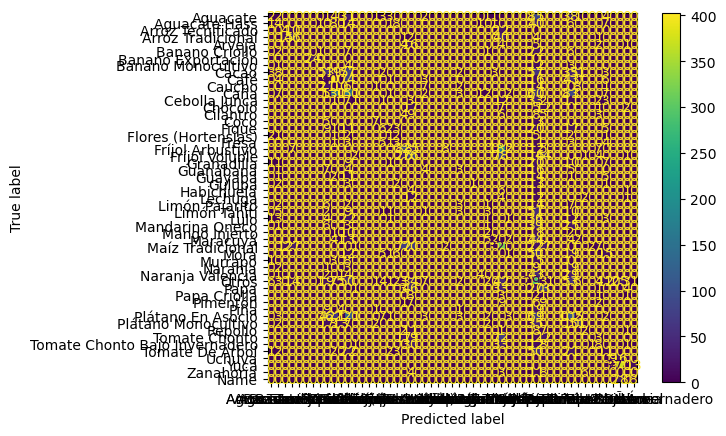



Modelo: SVC(C=10)


c:\Users\USUARIO\anaconda3\Lib\site-packages\category_encoders\ordinal.py:210: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[column].fillna(-1, inplace=True)


El accuracy del modelo es: 0.32151047240483105
El recall del modelo es: 0.17249082093892004
La precision del modelo es: 0.18799959004069478
El f1 del modelo es: 0.16612358236286265


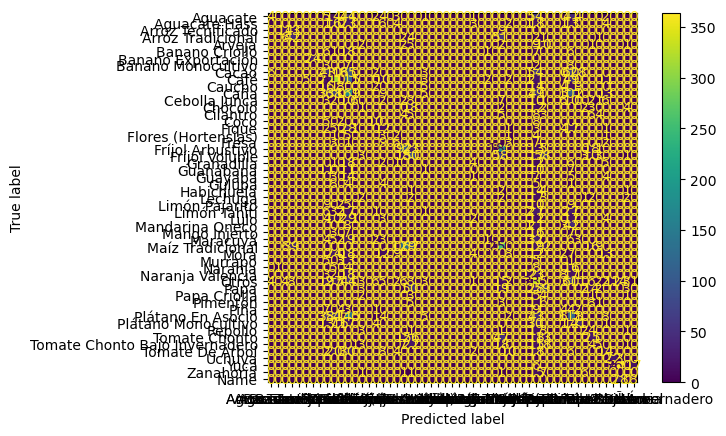



Modelo: KNeighborsClassifier()
El accuracy del modelo es: 0.3048463537685369
El recall del modelo es: 0.21600229698551557


c:\Users\USUARIO\anaconda3\Lib\site-packages\category_encoders\ordinal.py:210: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[column].fillna(-1, inplace=True)


La precision del modelo es: 0.27443912957744204
El f1 del modelo es: 0.22118846055859975


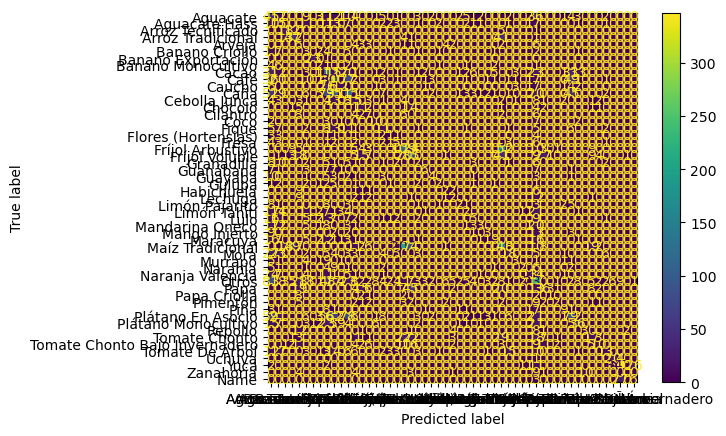



Modelo: DecisionTreeClassifier()
El accuracy del modelo es: 0.7176272741171075
El recall del modelo es: 0.6469754057101073
La precision del modelo es: 0.6386419100791288
El f1 del modelo es: 0.6367107808880655


c:\Users\USUARIO\anaconda3\Lib\site-packages\category_encoders\ordinal.py:210: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[column].fillna(-1, inplace=True)


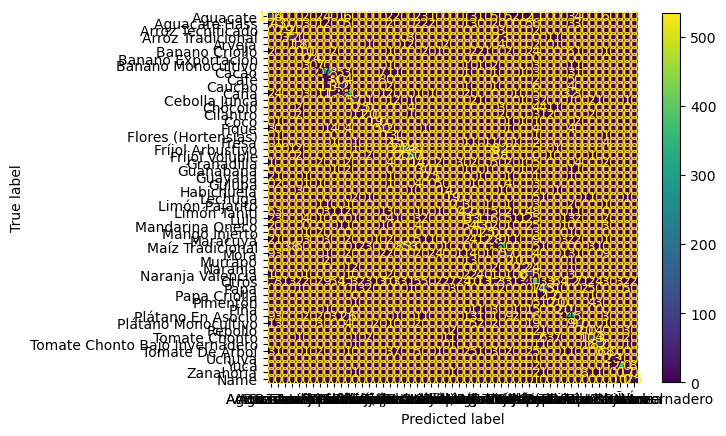



Modelo: RandomForestClassifier(criterion='entropy')


c:\Users\USUARIO\anaconda3\Lib\site-packages\category_encoders\ordinal.py:210: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[column].fillna(-1, inplace=True)


El accuracy del modelo es: 0.8223513224277633
El recall del modelo es: 0.7568342822767666
La precision del modelo es: 0.7832049133049355
El f1 del modelo es: 0.766566088835369


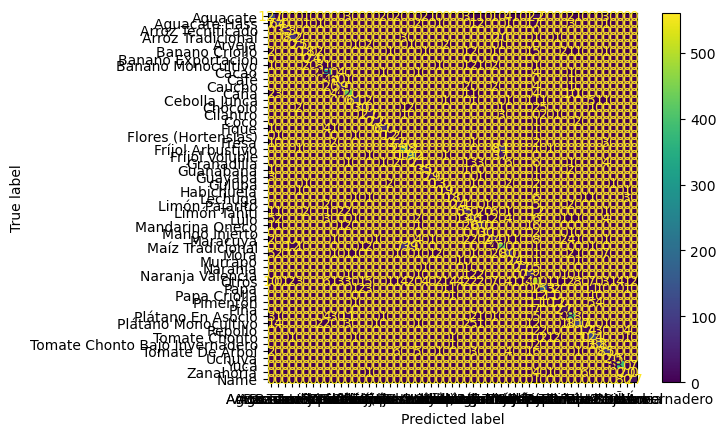



Modelo: GaussianNB(var_smoothing=1e-08)
El accuracy del modelo es: 0.09448096621311726
El recall del modelo es: 0.19023827544235658
La precision del modelo es: 0.13896578477260693
El f1 del modelo es: 0.06667592736081353


c:\Users\USUARIO\anaconda3\Lib\site-packages\category_encoders\ordinal.py:210: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[column].fillna(-1, inplace=True)


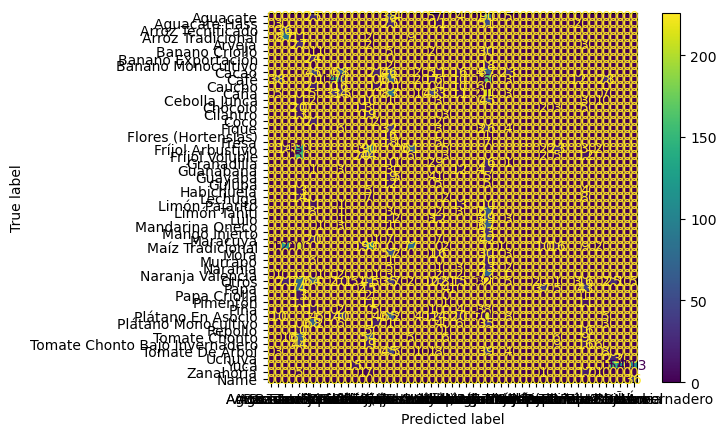

In [ ]:
#recorremos la lista que tiene los mejores modelos
#imprimimos las métricas para cada modelo

for i in lista_pipelines:
    print(f'Modelo: {i[-1]}')
    y_pred = i.predict(X_test)
    print(f'El accuracy del modelo es: {accuracy_score(y_test, y_pred)}')
    print(f'El recall del modelo es: {recall_score(y_test, y_pred, average="macro", zero_division=0)}')
    print(f'La precision del modelo es: {precision_score(y_test, y_pred, average="macro", zero_division=0)}')
    print(f'El f1 del modelo es: {f1_score(y_test, y_pred, average="macro", zero_division=0)}')

    mc = confusion_matrix(y_test, y_pred)
    image_matriz = ConfusionMatrixDisplay(confusion_matrix = mc, display_labels=le.classes_)
    image_matriz.plot()
    plt.show()
    
    print('\n')

Conclusiones

La variable dependiente presenta un desbalance prominente

las variables independientes con mejor correlación con la variable dependiente son:
-Municipio
-Tipo
-Volumen produccion
-Subregion

Los modelos con mejor rendimiento son:
RandomForestClassifier
    El accuracy del modelo es: 0.8223513224277633
    El recall del modelo es: 0.7568342822767666
    La precision del modelo es: 0.7832049133049355
    El f1 del modelo es: 0.766566088835369

DecisionTreeClassifier
El accuracy del modelo es: 0.7176272741171075
El recall del modelo es: 0.6469754057101073
La precision del modelo es: 0.6386419100791288
El f1 del modelo es: 0.6367107808880655

Coincidiendo con los 2 modelos de Orange con mejor rendimiento

La matriz de confusión queda ilegible por la gran cantidad de valores únicos de la variable dependiente
